# Workflow Pattern: Orchestration

<img src='../assets/orchestrator1.png' width='800' />

<img src='../assets/orchestrator.png' width='800' />

## Orchestrator-Worker Pattern

The orchestrator-worker pattern is a powerful approach for handling complex, unpredictable tasks by dynamically **breaking them into manageable pieces** and **processing them in parallel**. When you can't predict upfront how many subtasks you'll need or what they'll involve, this pattern shines by intelligently **analyzing** the input, **decomposing** it into structured work units, and **assigning** specialized workers to handle each piece independently.

Think of it like a busy catering kitchen that takes orders for large events—when a customer orders "I want a three-course meal, hamburgers for lunch, and pizza for dinner," the head chef (orchestrator) analyzes the request and breaks it down into specific dishes, then assigns specialized culinary consultants to create detailed meal plans for each cuisine. Each consultant specializes in a specific cuisine, for example, one expert in Italian cuisine handles the pizza planning, while an American cuisine specialist develops the hamburger menu. The key is that each consultant receives a **clear, structured brief** with dish requirements and dietary considerations, not just "plan something good." In our meal planning system, user requests such as "feed my family for the week" could result in anywhere from 3 to 15 different dishes, each requiring a specialist consultant's expertise in their particular cuisine to create comprehensive meal plans.

## Build a parallel meal planning system that coordinates multiple AI chefs

In [1]:
from langgraph.graph import StateGraph, END, START
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

from typing import TypedDict, Annotated, List, Literal
from pydantic import BaseModel, Field
import operator
from pprint import pprint

from IPython.display import Image, display

In [3]:
llm = ChatOpenAI(model="gpt-4o-mini") # temperature=0.7

In [4]:
# Dish schema for a single dish
class Dish(BaseModel):
    name: str = Field(
        description="Name of the dish (for example, Spaghetti Bolognese, Chicken Curry)."
    )
    ingredients: List[str] = Field(
        description="List of ingredients needed for this dish, separated by commas."
    )
    location: str = Field(
        description="The cuisine or cultural origin of the dish (for example, Italian, Indian, Mexican)."
    )

# Dishes schema for a list of Dish objects
class Dishes(BaseModel):
    sections: List[Dish] = Field(
        description="A list of grocery sections, one for each dish, with ingredients."
    )

In [5]:
# construct a prompt template
dish_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are an assistant that generates a structured grocery list.\n\n"
        "The user wants to prepare the following meals: {meals}\n\n"
        "For each meal, return a section with:\n"
        "- the name of the dish\n"
        "- a comma-separated list of ingredients needed for that dish.\n"
        "- the cuisine or cultural origin of the food"
    )
])

In [6]:
# use LCEL to pipe the prompt to an LLM with a structured output of Dishes
planner_pipe = dish_prompt | llm.with_structured_output(Dishes)
# planner_pipe = dish_prompt | llm.bind_tools(Dishes) # same as above

# invoke the planner_pipe with example meals
planner_pipe.invoke({ "meals" : ["banana smoothie", "carrot cake"]})

{'sections': [{'name': 'Banana Smoothie',
   'ingredients': ['bananas', 'milk', 'yogurt', 'honey', 'ice cubes'],
   'location': 'American'},
  {'name': 'Carrot Cake',
   'ingredients': ['carrots',
    'flour',
    'sugar',
    'eggs',
    'baking powder',
    'cinnamon',
    'vegetable oil',
    'vanilla extract',
    'cream cheese',
    'walnuts'],
   'location': 'American'}]}

### State (Orchestration)

In [7]:
class State(TypedDict):
    meals: str  # The user's input listing the meals to prepare
    sections: List[Dish] # One section per meal/dish with ingredients
    completed_menu: Annotated[List[str], operator.add]  # Worker written dish guide chunks
    final_meal_guide: str  # Fully compiled, readable menu

`"operator.add" automatically aggregate results from all parallel workers`

In [8]:
# create a dummy state to test our worker nodes
dummy_state: State = {
    "meals": "Spaghetti Bolognese and Chicken Stir Fry",
    "sections": [],
    "completed_menu": [],
    "final_meal_guide": ""
}

report_sections = planner_pipe.invoke({"meals": dummy_state['meals']})

In [12]:
report_sections

{'sections': [{'name': 'Spaghetti Bolognese',
   'ingredients': ['spaghetti',
    'ground beef',
    'onion',
    'garlic',
    'carrot',
    'celery',
    'canned tomatoes',
    'olive oil',
    'salt',
    'pepper',
    'basil',
    'parmesan cheese'],
   'location': 'Italian'},
  {'name': 'Chicken Stir Fry',
   'ingredients': ['chicken breast',
    'bell peppers',
    'broccoli',
    'carrot',
    'soy sauce',
    'ginger',
    'garlic',
    'onion',
    'vegetable oil',
    'salt',
    'pepper',
    'rice'],
   'location': 'Chinese'}]}

In [34]:
for i, section in enumerate(report_sections['sections']):
    print(f"Dish {i+1}\n")
    # add each dish to our dummy state
    dummy_state["sections"].append(section)
    print(f"Item Name: {section['name']}")
    print(f"Location/Cuisine: {section['location']}")
    print(f"Ingredients: {', '.join(section['ingredients'])}.")

Dish 1

Item Name: Spaghetti Bolognese
Location/Cuisine: Italian
Ingredients: spaghetti, ground beef, onion, garlic, carrot, celery, canned tomatoes, olive oil, salt, pepper, basil, parmesan cheese.
Dish 2

Item Name: Chicken Stir Fry
Location/Cuisine: Chinese
Ingredients: chicken breast, bell peppers, broccoli, carrot, soy sauce, ginger, garlic, onion, vegetable oil, salt, pepper, rice.


### Orchestrator Node

The **orchestrator** is responsible for high-level planning and acts as the central coordinator in the LangGraph workflow. It takes a user's input and produces structured subtasks for other nodes to handle.


In [46]:
def orchestrator(state: State):
    """Orchestrator that generates a structured dish list from the given meals."""

    # use the planner_pipe LLM to break the user's meal list into structured dish sections
    dish_descriptions = planner_pipe.invoke({"meals": state["meals"]})
    print('------------------- dish_descriptions -------------------------')
    print(dish_descriptions)
    print('------------------- dish_descriptions -------------------------')

    # return the list of dish sections to be passed to worker nodes
    return {"sections": dish_descriptions['sections']}

### Worker Nodes

- Each **worker node** processes a single unit of work, typically one item from `state["sections"]`.
- Workers are designed to be **isolated** so they only see a slice of the state and return an output.
- In our case, each worker will be a chef.


In [16]:
chef_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a world-class chef from {location}.\n\n"
        "Please introduce yourself briefly and present a detailed walkthrough for preparing the dish: {name}.\n"
        "Your response should include:\n"
        "- Start with hello with your  name and culinary background\n"
        "- A clear list of preparation steps\n"
        "- A full explanation of the cooking process\n\n"
        "Use the following ingredients: {ingredients}."
    )
])

In [17]:
chef_pipe = chef_prompt | llm

In [18]:
class WorkerState(TypedDict):
    section: Dish
    completed_menu: Annotated[list, operator.add] # list with addition operators between elements

- The `assign_workers` function extracts each `Dish` object from the `sections` key and passes it to the worker node `chef_worker`. 
- `Send()` function passes `s` to the `chef_worker` node via the `section` key.


In [19]:
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("chef_worker", {"section": s}) for s in state["sections"]]

In [47]:
def chef_worker(state: WorkerState):
    """Worker node that generates the cooking instructions for one meal section."""

    # Use the language model to generate a meal preparation plan
    # The model receives the dish name, location, and ingredients from the current section
    meal_plan = chef_pipe.invoke({
        "name": state["section"]['name'],
        "location": state["section"]['location'],
        "ingredients": state["section"]['ingredients']
    })
    print('----------------- meal_plan -----------------')
    print(meal_plan)
    print('----------------- meal_plan -----------------')

    # Return the generated meal plan wrapped in a list under completed_sections
    # This will be merged into the main state using operator.add in LangGraph
    return {"completed_menu": [meal_plan.content]}


In [23]:
dummy_dishes: List[Dish] = dummy_state["sections"]

# simulate LangGraph's fan-out and merging behavior
for section in dummy_dishes:
    # construct individual WorkerState
    worker_state: WorkerState = {
        "section": section,
        "recipe": []  # LangGraph merges this later
    }

    # call the worker logic directly
    result = chef_worker(worker_state)

    # merge the result into combined menu (LangGraph would do this with operator.add)
    dummy_state["completed_menu"] += result["completed_menu"]

In [28]:
completed_menu_sections = "\n".join(dummy_state["completed_menu"])
print(completed_menu_sections[:1000])

Buongiorno! My name is Giovanni, and I am an Italian chef with over 15 years of culinary experience, specializing in traditional Italian cuisine. Today, I will guide you through the delightful process of making a classic Spaghetti Bolognese—a dish that embodies the heart of Italian cooking with its rich flavors and comforting essence. 

### Ingredients:
- 400g spaghetti
- 500g ground beef
- 1 medium onion, finely chopped
- 2 cloves garlic, minced
- 1 medium carrot, finely diced
- 1 celery stalk, finely diced
- 400g canned tomatoes (crushed or diced)
- 2 tablespoons olive oil
- Salt, to taste
- Black pepper, to taste
- Fresh basil leaves (or dried basil)
- Grated Parmesan cheese, for serving

### Preparation Steps:
1. **Prepare the Ingredients:**
   - Finely chop the onion, garlic, carrot, and celery.
   - Open the can of tomatoes and set aside.

2. **Cook the Spaghetti:**
   - Bring a large pot of salted water to a boil. Add the spaghetti and cook according to package instructions unti

In [29]:
def synthesizer(state: State):
    """Synthesize full report from sections"""

    # list of completed sections
    completed_sections = state["completed_menu"]

    # format completed section to str to use as context for final sections
    completed_menu = "\n\n---\n\n".join(completed_sections)

    return {"final_meal_guide": completed_menu}

### Building the Workflow (Orchestration)

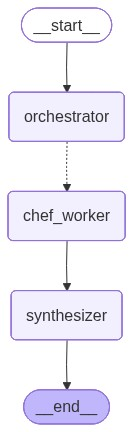

In [48]:
# instantiate the builder
orchestrator_worker_builder = StateGraph(State)

# add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("chef_worker", chef_worker)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["chef_worker"] # source node, routing function, list of allowed targets
)

# add the edges, connections between nodes
orchestrator_worker_builder.add_edge("chef_worker", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# compile the builder to get a complete workflow executable
orchestrator_worker = orchestrator_worker_builder.compile()
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

`In above diagram, From orchestrator to chef_worker, there is dotted line. Means: chef_worker could be one or more`

In [49]:
# invoke the workflow with a string of meals in a dict
state = orchestrator_worker.invoke({"meals": "Steak and eggs, tacos, and chili"})

------------------- dish_descriptions -------------------------
{'sections': [{'name': 'Steak and Eggs', 'ingredients': ['steak', 'eggs', 'salt', 'pepper', 'butter'], 'location': 'American'}, {'name': 'Tacos', 'ingredients': ['taco shells', 'ground beef', 'lettuce', 'tomato', 'cheese', 'sour cream', 'taco seasoning'], 'location': 'Mexican'}, {'name': 'Chili', 'ingredients': ['ground beef', 'kidney beans', 'black beans', 'tomato sauce', 'onion', 'garlic', 'chili powder'], 'location': 'American'}]}
------------------- dish_descriptions -------------------------
----------------- meal_plan -----------------
content="Hello! My name is Chef Alex, and I have spent over a decade honing my culinary skills in various kitchens across the United States. I have a deep passion for creating comforting, hearty dishes that bring people together. Today, I'm excited to share with you a classic American breakfast favorite: Steak and Eggs. This dish is not only delicious but also packed with protein, maki

In [50]:
# print the first 2000 characters of our final_meal_guide
pprint(state["final_meal_guide"][:2000])

('Hello! My name is Chef Alex, and I have spent over a decade honing my '
 'culinary skills in various kitchens across the United States. I have a deep '
 'passion for creating comforting, hearty dishes that bring people together. '
 "Today, I'm excited to share with you a classic American breakfast favorite: "
 'Steak and Eggs. This dish is not only delicious but also packed with '
 'protein, making it a perfect start to your day.\n'
 '\n'
 '### Ingredients:\n'
 '- Steak (your choice: ribeye, sirloin, or filet mignon)\n'
 '- Eggs (2 per serving)\n'
 '- Salt (to taste)\n'
 '- Pepper (to taste)\n'
 '- Butter (2 tablespoons)\n'
 '\n'
 '### Preparation Steps:\n'
 '1. **Choose Your Steak**: Select a cut of steak that suits your preference. '
 'Ribeye is known for its marbling and flavor, while sirloin is leaner and '
 'more budget-friendly.\n'
 '  \n'
 '2. **Bring Steak to Room Temperature**: Remove the steak from the fridge and '
 'let it sit at room temperature for about 30 minutes befor